In [35]:
# import important libraries
import pandas as pd
import numpy as np
from faker import Faker
import random
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# creating dataframe using faker and random function
fake = Faker()

np.random.seed(42)

rows = 5000

data = {
    "order_id": np.arange(1, rows + 1),
    "customer_name": [fake.name() for _ in range(rows)],
    "city": [fake.city() for _ in range(rows)],
    "delivery_time_mins": np.random.randint(20, 180, rows),
    "on_time_delivery": np.random.choice([0, 1], rows, p=[0.2, 0.8]),
    "inventory_available": np.random.choice([0, 1], rows, p=[0.1, 0.9]),
    "order_value": np.random.randint(10, 500, rows),
    "checkout_completed": np.random.choice([0, 1], rows, p=[0.3, 0.7]),
    "ab_test_group": np.random.choice(["A", "B"], rows),
    "coupon_used": np.random.choice([0, 1], rows, p=[0.6, 0.4])
}

df = pd.DataFrame(data)

In [7]:
df.head(10)

,order_id,customer_name,city,delivery_time_mins,on_time_delivery,inventory_available,order_value,checkout_completed,ab_test_group,coupon_used
0,1,Dennis Jacobson,Clarkchester,122,1,1,136,0,A,0
1,2,Tara Guerrero,Johnsontown,112,1,1,255,1,B,0
2,3,Jonathan Hardy,Kathleentown,34,0,1,96,0,A,1
3,4,Helen Krueger,Robertburgh,126,0,1,488,0,A,0
4,5,James Byrd,Kendramouth,91,1,1,86,1,B,0
5,6,Mark Mendoza,Leonshire,40,1,1,386,1,B,0
6,7,Amy Quinn,Sarahville,122,1,1,213,0,A,0
7,8,David Owens,Colemanchester,141,1,1,492,1,B,0
8,9,Thomas Davis,Port Michaelfurt,94,1,1,155,1,B,1
9,10,Willie Combs,New Jennifer,107,1,0,158,0,A,0


# Data cleaning 

In [9]:
# checking missing values
df.isnull().sum().sum()

0

In [10]:
# removing duplicates
df.drop_duplicates(inplace=True)

In [41]:
# Create abandonment column
df["cart_abandoned"] = np.where(
    df["checkout_completed"] == 0,
    1,
    0
)

df.head(10)

,order_id,customer_name,city,delivery_time_mins,on_time_delivery,inventory_available,order_value,checkout_completed,ab_test_group,coupon_used,late_delivery,cart_abandoned
0,1,Dennis Jacobson,Clarkchester,122,1,1,136,0,A,0,1,1
1,2,Tara Guerrero,Johnsontown,112,1,1,255,1,B,0,1,0
2,3,Jonathan Hardy,Kathleentown,34,0,1,96,0,A,1,0,1
3,4,Helen Krueger,Robertburgh,126,0,1,488,0,A,0,1,1
4,5,James Byrd,Kendramouth,91,1,1,86,1,B,0,1,0
5,6,Mark Mendoza,Leonshire,40,1,1,386,1,B,0,0,0
6,7,Amy Quinn,Sarahville,122,1,1,213,0,A,0,1,1
7,8,David Owens,Colemanchester,141,1,1,492,1,B,0,1,0
8,9,Thomas Davis,Port Michaelfurt,94,1,1,155,1,B,1,1,0
9,10,Willie Combs,New Jennifer,107,1,0,158,0,A,0,1,1


In [42]:
# converting datatypes in required formats
df["delivery_time_mins"] = df["delivery_time_mins"].astype(int)

In [43]:
#creating KPI columns
df["late_delivery"] = np.where(df["delivery_time_mins"] > 90, 1, 0)

In [44]:
df.head(10)

,order_id,customer_name,city,delivery_time_mins,on_time_delivery,inventory_available,order_value,checkout_completed,ab_test_group,coupon_used,late_delivery,cart_abandoned
0,1,Dennis Jacobson,Clarkchester,122,1,1,136,0,A,0,1,1
1,2,Tara Guerrero,Johnsontown,112,1,1,255,1,B,0,1,0
2,3,Jonathan Hardy,Kathleentown,34,0,1,96,0,A,1,0,1
3,4,Helen Krueger,Robertburgh,126,0,1,488,0,A,0,1,1
4,5,James Byrd,Kendramouth,91,1,1,86,1,B,0,1,0
5,6,Mark Mendoza,Leonshire,40,1,1,386,1,B,0,0,0
6,7,Amy Quinn,Sarahville,122,1,1,213,0,A,0,1,1
7,8,David Owens,Colemanchester,141,1,1,492,1,B,0,1,0
8,9,Thomas Davis,Port Michaelfurt,94,1,1,155,1,B,1,1,0
9,10,Willie Combs,New Jennifer,107,1,0,158,0,A,0,1,1


# Exploratory Data Analysis (EDA)

In [45]:
# Average delivery time
round(df["delivery_time_mins"].mean(), 2)


100.66

In [46]:
# On-Time Delivery %
on_time = df["on_time_delivery"].mean() * 100
print(f"On-Time Delivery %: {on_time:.2f}")

On-Time Delivery %: 79.50


In [47]:
# Checkout Conversion Rate
conversion = df["checkout_completed"].mean() * 100
print(f"Checkout Conversion Rate: {conversion:.2f}")

Checkout Conversion Rate: 69.10


# Cart Abandonment Rate

In [48]:
abandonment_rate = (
    df["cart_abandoned"].mean() * 100
)

print(f"Cart Abandonment Rate: {abandonment_rate:.2f}%")

Cart Abandonment Rate: 30.90%


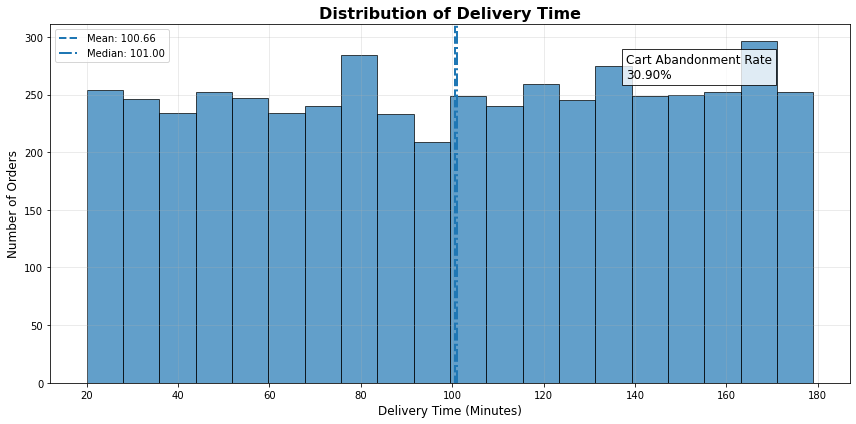

In [49]:
# Mean and median
mean_time = df["delivery_time_mins"].mean()
median_time = df["delivery_time_mins"].median()

# Cart abandonment rate
cart_abandon_rate = (
    df["cart_abandoned"].mean() * 100
)

# Create figure
plt.figure(figsize=(12,6))

# Histogram
plt.hist(
    df["delivery_time_mins"],
    bins=20,
    edgecolor="black",
    alpha=0.7
)

# Mean line
plt.axvline(
    mean_time,
    linestyle="--",
    linewidth=2,
    label=f"Mean: {mean_time:.2f}"
)

# Median line
plt.axvline(
    median_time,
    linestyle="-.",
    linewidth=2,
    label=f"Median: {median_time:.2f}"
)

# KPI Text Box
plt.text(
    0.72,
    0.85,
    f"Cart Abandonment Rate\n{cart_abandon_rate:.2f}%",
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(
        facecolor="white",
        alpha=0.8,
        edgecolor="black"
    )
)

# Labels and title
plt.xlabel(
    "Delivery Time (Minutes)",
    fontsize=12
)

plt.ylabel(
    "Number of Orders",
    fontsize=12
)

plt.title(
    "Distribution of Delivery Time",
    fontsize=16,
    fontweight="bold"
)

# Grid
plt.grid(alpha=0.3)

# Legend
plt.legend()

# Better spacing
plt.tight_layout()

# Show plot
plt.show()

# A/B Test Conversion Comparison

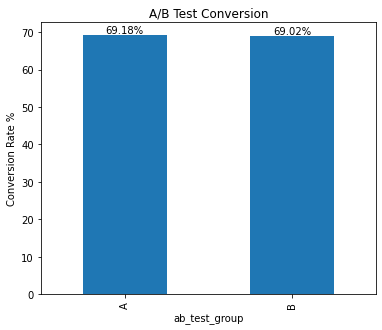

In [37]:
ab_summary = df.groupby("ab_test_group")["checkout_completed"].mean() * 100

plt.figure(figsize=(6,5))

ab_summary.plot(kind="bar")

plt.ylabel("Conversion Rate %")
plt.title("A/B Test Conversion")

for i, v in enumerate(ab_summary.values):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')

plt.show()